In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.insert(0, "../scripts")
#sys.path.insert(0, "../analysis_tools")
from muon_range_lookup import *
#from analysis_tools import DataLoader

In [55]:
import pickle
folder = '/eos/user/j/jrimmer/SWAN_projects/beam/LF_multiParticles/outputs/'
energy = 356.6
energy = 304.8
#energy = 172

run = 2079
#run = 1580

beam_p = 430
#beam_p = 280
#energy = 300
#with open(folder+'estimates_300MeV_batches_x0y0zn1350_noScat_ringOnly_sin_pe&t.dict','rb') as f:
#with open(folder+'estimates_300MeV_batches_x0y0zn1330_ringOnly_nfit.dict','rb') as f:
with open(folder+'estimates_run'+str(run)+'_'+str(beam_p)+'p_muon_full_length_mpmtEff_charge_time.dict','rb') as f:   
    est = pickle.load(f)

# with open('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/work_dir/estimates/estimates_300MeV_batches_x0y0zn1330_charge_only_design_multistage.dict','rb') as f:   
#     est = pickle.load(f)

In [56]:
beam_p = 257
m = 105.56
ke_meas = np.sqrt(beam_p**2+m**2) - m
ke_meas

np.float64(172.27432761269802)

In [57]:
length_t = muon_energy_to_range_mm(energy)
#length_t = muon_energy_to_range_mm(300)

In [58]:
length_t

1197.6012817780575

In [71]:
mask = (np.asarray(est["est_fcn"]) < 1200) & (np.asarray(est["n_attempts"]) < 2)
n = len(mask)

est_cut = {}

for key, value in est.items():
    arr = np.asarray(value)

    # Only mask entries that have one value per event
    if arr.ndim > 0 and len(arr) == n:
        est_cut[key] = arr[mask]
    else:
        # Keep scalar / metadata entries unchanged
        est_cut[key] = value

None


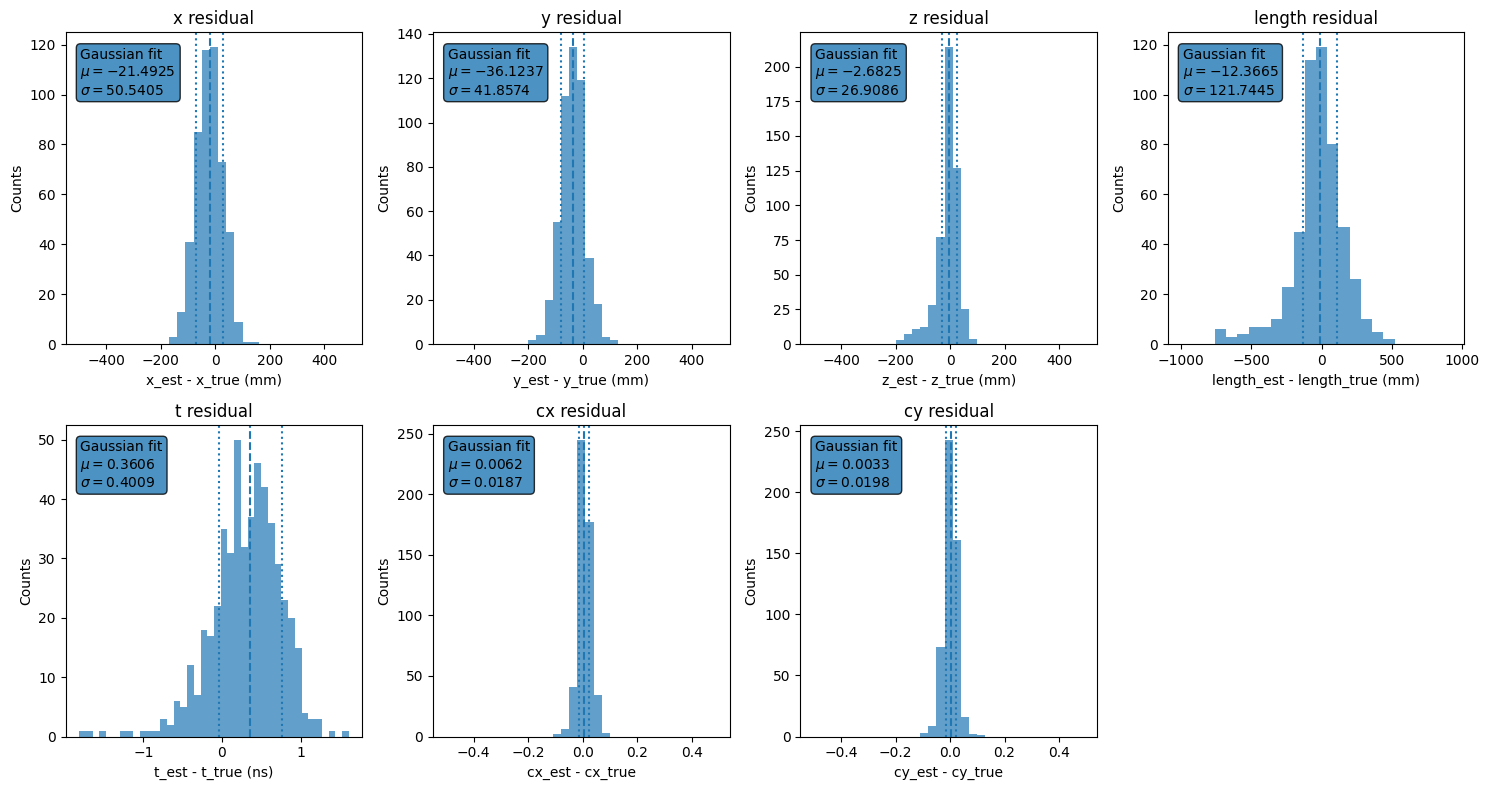

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = est_cut
show_gaussian_fits = False

truth = {
    'x': 0.0,
    'y': 0,
    'z': -1348,
    'length': length_t,
    't': 0.0,
    'cx': 0.0,
    'cy': 0.0,
}

keys_to_plot = ['x', 'y', 'z', 'length', 't', 'cx', 'cy']
vertex = ['x', 'y', 'z']
distance = ['x','y','z','length' ]
time = ['t']
direction = ['cx','cy']

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)


def fit_central_gaussian_from_hist(residuals, bins, fit_window_sigma=2.0):
    residuals = np.asarray(residuals)
    residuals = residuals[np.isfinite(residuals)]

    counts, edges = np.histogram(residuals, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = np.mean(np.diff(edges))

    if len(residuals) < 10 or np.max(counts) == 0:
        return np.nan, np.nan, None, counts, edges

    # Robust initial estimates from central part of data
    med = np.nanmedian(residuals)
    mad = np.nanmedian(np.abs(residuals - med))
    sigma_robust = 1.4826 * mad

    if not np.isfinite(sigma_robust) or sigma_robust <= 0:
        sigma_robust = np.nanstd(residuals)

    # Fit only bins near the central peak
    fit_mask = (
        (centers >= med - fit_window_sigma * sigma_robust)
        & (centers <= med + fit_window_sigma * sigma_robust)
        & (counts > 0)
    )

    x_fit = centers[fit_mask]
    y_fit = counts[fit_mask]

    if len(x_fit) < 4:
        return med, sigma_robust, None, counts, edges

    A0 = np.max(y_fit)
    mu0 = x_fit[np.argmax(y_fit)]
    sigma0 = sigma_robust

    try:
        popt, _ = curve_fit(
            gaussian,
            x_fit,
            y_fit,
            p0=[A0, mu0, sigma0],
            bounds=(
                [0, np.min(x_fit), 0],
                [np.inf, np.max(x_fit), np.inf]
            ),
            maxfev=10000
        )

        A_fit, mu_fit, sigma_fit = popt
        sigma_fit = abs(sigma_fit)

        return mu_fit, sigma_fit, popt, counts, edges

    except RuntimeError:
        return med, sigma_robust, None, counts, edges


fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, key in enumerate(keys_to_plot):
    ax = axes[i]

    values = np.asarray(data[key])
    residuals = values - truth[key]
    residuals = residuals[np.isfinite(residuals)]

    if key in vertex:
        bins = np.arange(-500, 500, 30)
    elif key in distance:
        bins = np.arange(-1000, 1000, 80)
    elif key in direction:
        bins = np.arange(-0.5,0.5,0.03)
        
    else:
        bins = 40
        
        
    #bins = 40

    mean_fit, std_fit, popt, counts, hist_bins = fit_central_gaussian_from_hist(
        residuals,
        bins=bins,
        fit_window_sigma=2.0
    )

    ax.hist(residuals, bins=hist_bins, alpha=0.7)

    ax.axvline(mean_fit, linestyle='--')
    ax.axvline(mean_fit + std_fit, linestyle=':')
    ax.axvline(mean_fit - std_fit, linestyle=':')

    if show_gaussian_fits and popt is not None:
        x_curve = np.linspace(hist_bins[0], hist_bins[-1], 1000)
        y_curve = gaussian(x_curve, *popt)
        ax.plot(x_curve, y_curve, linewidth=2)

    ax.set_title(f"{key} residual")
    if key in distance:
        ax.set_xlabel(f"{key}_est - {key}_true (mm)")
    elif key in time:
        ax.set_xlabel(f"{key}_est - {key}_true (ns)")
        
    else:
        ax.set_xlabel(f"{key}_est - {key}_true")
    ax.set_ylabel("Counts")

    textstr = (
        f"Gaussian fit\n"
        f"$\\mu = {mean_fit:.4f}$\n"
        f"$\\sigma = {std_fit:.4f}$"
    )

    ax.text(
        0.05, 0.95, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle="round", alpha=0.8)
    )
    if key == 'z':
        print(popt)

for j in range(len(keys_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [35]:
est.keys()

dict_keys(['metadata', 'minimum_found', 'x', 'y', 'z', 'visible_length', 'full_range', 'ke0', 'length', 't', 'est_fcn', 'true_fcn', 'cx', 'cy', 'n_attempts', 'chosen_seed_idx', 'chosen_seed_fcn', 'chosen_seed_params', 'adaptive_rescue_used', 'length_profile_rescue_considered', 'length_profile_rescue_used', 'fcn_retry_used', 'edm'])

In [50]:
est['chosen_seed_fcn'][145]

2302.522282574867

In [54]:
est['length'][168]

565.9710257205273

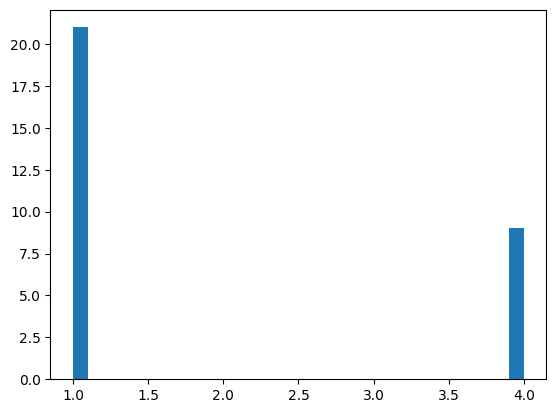

In [43]:
mask = np.array(est['z'])<-1450
bins= 30#np.arange(-3,3,0.1)
#np.array(est['chosen_seed_params'])[mask]

plt.hist(np.array(est['n_attempts'])[mask],bins=bins);

Text(0.5, 0, 'n_attempts')

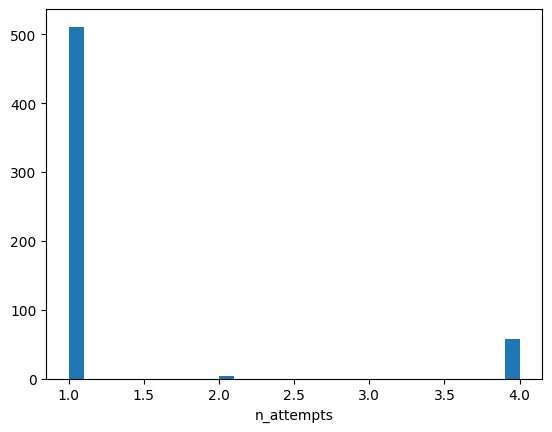

In [44]:
bins = np.arange(0,2000,30)
bins = 30
plt.hist(est['n_attempts'],bins = bins);
plt.xlabel('n_attempts')

In [18]:
(1000**2)/(1.344*105*5**3)

56.68934240362812

In [21]:
np.sin(42*np.pi/180)**2*1000

np.float64(447.7357683661733)

In [8]:
mask = np.array(est['z']) <-1400

In [9]:
len(np.array(est['length'])[mask])

17

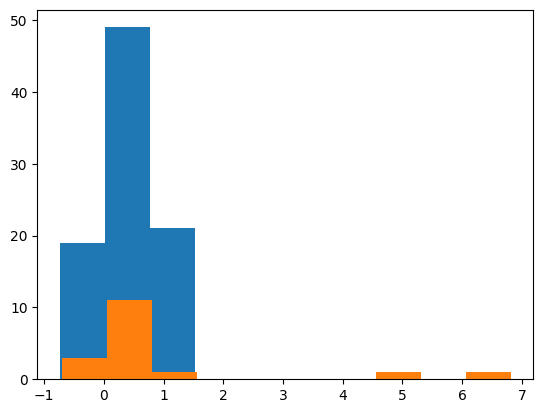

In [10]:
plt.hist(np.array(est['t']));
plt.hist(np.array(est['t'])[mask]);

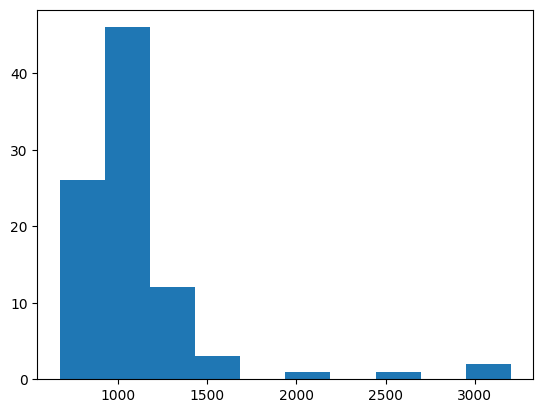

In [11]:
plt.hist(np.array(est['est_fcn']));

In [12]:
with open('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/tables/rel_mpmt_eff.dict', 'rb') as f:
    d = pickle.load(f)
    


In [14]:
len(d['tri_exsitu'])

61

In [24]:
cost_for_fit = np.linspace(0,1,len(d['tri_insitu']))
cost

array([0.        , 0.01666667, 0.03333333, 0.05      , 0.06666667,
       0.08333333, 0.1       , 0.11666667, 0.13333333, 0.15      ,
       0.16666667, 0.18333333, 0.2       , 0.21666667, 0.23333333,
       0.25      , 0.26666667, 0.28333333, 0.3       , 0.31666667,
       0.33333333, 0.35      , 0.36666667, 0.38333333, 0.4       ,
       0.41666667, 0.43333333, 0.45      , 0.46666667, 0.48333333,
       0.5       , 0.51666667, 0.53333333, 0.55      , 0.56666667,
       0.58333333, 0.6       , 0.61666667, 0.63333333, 0.65      ,
       0.66666667, 0.68333333, 0.7       , 0.71666667, 0.73333333,
       0.75      , 0.76666667, 0.78333333, 0.8       , 0.81666667,
       0.83333333, 0.85      , 0.86666667, 0.88333333, 0.9       ,
       0.91666667, 0.93333333, 0.95      , 0.96666667, 0.98333333,
       1.        ])

In [23]:
def interp_by_mpmt_type(cost, mpmt_types, cost_for_fit,
                        tri_exsitu, tri_insitu, wut_exsitu, wut_insitu,
                        fill_empty=np.nan):
    cost = np.asarray(cost, dtype=float)
    mpmt_types = np.asarray(mpmt_types)
    cost_for_fit = np.asarray(cost_for_fit, dtype=float)

    out = np.full(cost.shape, fill_empty, dtype=float)

    y_by_type = {
        "tri_exsitu": np.asarray(tri_exsitu, dtype=float),
        "tri_insitu": np.asarray(tri_insitu, dtype=float),
        "wut_exsitu": np.asarray(wut_exsitu, dtype=float),
        "wut_insitu": np.asarray(wut_insitu, dtype=float),
    }

    for typ, yvals in y_by_type.items():
        mask = mpmt_types == typ
        if np.any(mask):
            out[mask] = np.interp(
                cost[mask],
                cost_for_fit,
                yvals,
                left=yvals[0],
                right=yvals[-1],
            )

    return out

In [26]:
interp_by_mpmt_type([0.1],['tri_exsitu'],cost_for_fit,d['tri_exsitu'],d['tri_insitu'],d['wut_exsitu'],d['wut_insitu'])




array([0.6259])

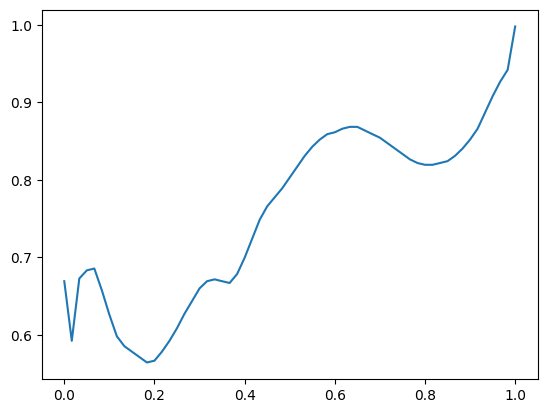

In [28]:
plt.plot(cost_for_fit,d['tri_exsitu'])

In [33]:
x = np.asarray([0,1,2,3])
y = np.asarray([4,5,6,7])

x*y

array([ 0,  5, 12, 21])

In [22]:
len(cost)

61

In [17]:
import json
with open('/eos/user/j/jrimmer/SWAN_projects/data_checks/led_mapping.json', 'rb') as f:
    
    m = json.load(f)

In [23]:
m
for card in m:
    if m[card]['slot_id'] == 14:
        print(card)

In [16]:
mpmt_info

{103: {'mpmt_type': 'Ex-situ',
  'mpmt_site': 'TRI',
  'led_pos': {0: {'led_type': 'Diffuser', 'wavelength': 470},
   4: {'led_type': '15deg', 'wavelength': 405},
   3: {'led_type': '15deg', 'wavelength': 365}}},
 70: {'mpmt_type': 'Ex-situ',
  'mpmt_site': 'WUT',
  'led_pos': {2: {'led_type': 'Diffuser', 'wavelength': 470},
   0: {'led_type': '15deg', 'wavelength': 405},
   1: {'led_type': '15deg', 'wavelength': 365}}},
 31: {'mpmt_type': 'In-situ',
  'mpmt_site': 'TRI',
  'led_pos': {0: {'led_type': '30deg', 'wavelength': 470},
   1: {'led_type': 'Diffuser', 'wavelength': 405},
   2: {'led_type': '30deg', 'wavelength': 365}}},
 95: {'mpmt_type': 'In-situ',
  'mpmt_site': 'TRI',
  'led_pos': {1: {'led_type': '30deg', 'wavelength': 470},
   0: {'led_type': 'Diffuser', 'wavelength': 405},
   2: {'led_type': '30deg', 'wavelength': 365}}},
 86: {'mpmt_type': 'In-situ',
  'mpmt_site': 'TRI',
  'led_pos': {0: {'led_type': '30deg', 'wavelength': 470},
   1: {'led_type': '30deg', 'wavelength'

In [15]:
est.keys()

dict_keys(['minimum_found', 'x', 'y', 'z', 'length', 't', 'est_fcn', 'true_fcn', 'cx', 'cy', 'n_attempts', 'chosen_seed_idx', 'chosen_seed_fcn', 'chosen_seed_params', 'seed_scan'])

In [7]:
est['chosen_seed_params']

[{'x0': 0.0,
  'y0': 0.0,
  'z0': -1500,
  'cx': 0.0,
  'cy': 0.0,
  'length': 1000.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1500,
  'cx': 0.0,
  'cy': 0.0,
  'length': 1000.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': 0.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1000.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1500,
  'cx': 0.0,
  'cy': 0.0,
  'length': 1000.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1000.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1000.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1500,
  'cx': 0.0,
  'cy': 0.0,
  'length': 1000.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1000.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3},
 {'x0': 0.0,
  'y0': 0.0,
  'z0': -1000.0,
  'cx': 0.0,
  'cy': 0.0,
  'length': 500.0,
  't0': -3}

In [8]:
est['chosen_seed_fcn']

[951.7832101419427,
 4584.79582459659,
 8510.03393976306,
 2465.2311459329358,
 906.5313913768681,
 2732.6472134309874,
 4834.264507205034,
 8463.020589630829,
 973.6681141768428,
 4211.318507223549,
 5506.054727879613,
 962.4894680116691,
 1262.8733585255306,
 8119.398886756489,
 539.5638883787243,
 5833.4114910995795,
 8948.23653744353,
 9356.662530981857,
 4678.274445144818,
 3457.0183351075198,
 8242.478595935716,
 8596.98420146161,
 7265.119326890656,
 8587.060866417036,
 9019.60161386208,
 4011.6609009131753,
 2520.108282151782,
 8176.053312723047,
 2278.145138950188,
 2825.1307049756883,
 2801.9403747603737,
 8655.798643089096,
 8279.71388078869,
 7767.887049891242,
 8236.023839821002,
 7948.708482981809,
 7749.420190110661,
 4401.630476641876,
 1235.8569467040336,
 7779.151563629842,
 8504.152140816755,
 9492.490438178333,
 7047.373756629816,
 1851.2111089025661,
 9796.682546783,
 7423.18955276855,
 1714.6254613046146,
 5617.284770518881,
 5912.067893579557,
 4445.8431246428745

In [8]:
est['est_fcn']

[769.4662310055862,
 671.7426031481226,
 721.6603846593226,
 657.3819735158409,
 771.5196807203773,
 899.9257367789635,
 873.3558603250622,
 719.8932359891113,
 758.1022575925341,
 678.0053433020731,
 679.2098630036069,
 768.1392316568626,
 803.7697300841281,
 771.7570330764103,
 248.27578138099804,
 752.3623972992718,
 792.6171567963519,
 658.9799885772456,
 988.7233172206171,
 860.6886869350436,
 800.794927520076,
 724.2452870221556,
 733.1945811297038,
 850.5153858463747,
 674.121342110553,
 822.772525981425,
 709.3271820102053,
 783.7977944545129,
 656.7216935198227,
 767.4471861889721,
 952.4331462787592,
 809.3727721603046,
 660.0193340705772,
 850.0183907817585,
 6938.529192014237,
 850.3983756123527,
 727.5648170802248,
 764.1627336590298,
 789.1556002885585,
 833.0602002249899,
 1091.3815644601193,
 5241.768106851202,
 804.5625003736499,
 862.2282081496281,
 760.6323231255933,
 935.7687623174013,
 672.4765787526,
 670.5721197527415,
 633.4735979493449,
 852.1552084201794,
 647

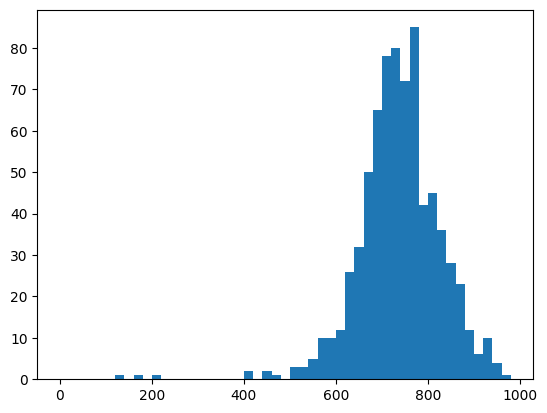

In [15]:
plt.hist(est['est_fcn'],bins = np.arange(0,1000,20));

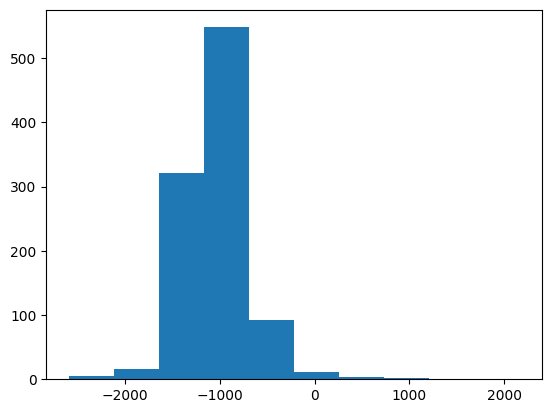

In [34]:
plt.hist(est['est_fcn'],bins = 10);

In [35]:
mask = np.array(est['est_fcn'])>1000

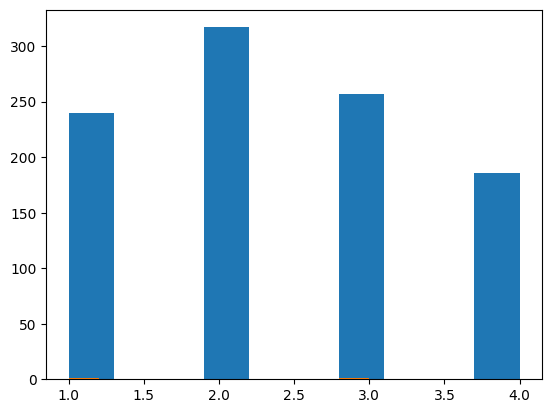

In [36]:
plt.hist(est['n_attempts'],bins = 10);
plt.hist(np.array(est['n_attempts'])[mask],bins = 10);

In [14]:
mask = np.array(est['t'])<0

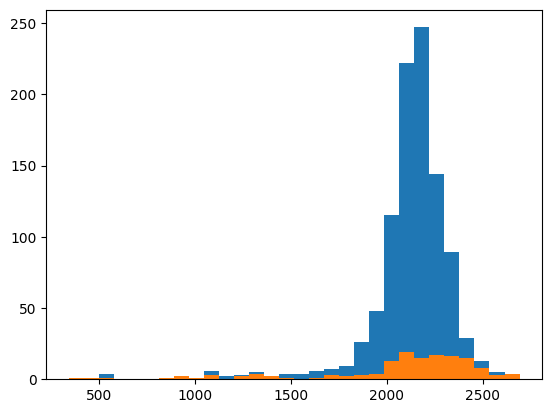

In [17]:
bins = np.arange(-1700,-1000,50)
bins = 30
plt.hist(np.array(est['length']),bins = bins);
plt.hist(np.array(est['length'])[mask],bins = bins);

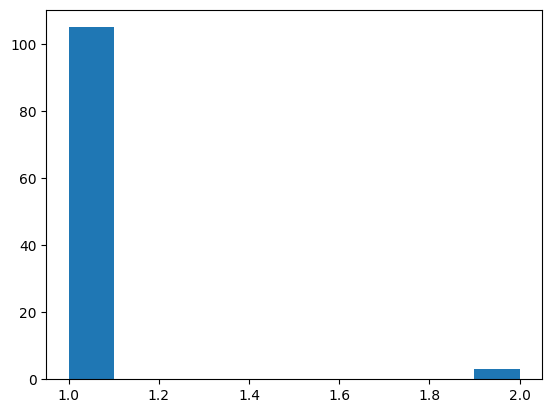

In [10]:
plt.hist(np.array(est['n_attempts'])[mask]);

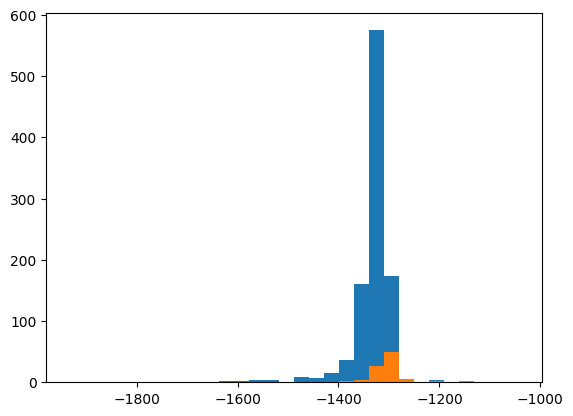

In [10]:
bins =np.arange(100,700,5)
bins = 30
plt.hist(np.array(est['z']),bins = bins);
plt.hist(np.array(est['z'])[mask],bins = bins);

In [18]:
sys.path.insert(0, "./scripts")

from read_sim_data import *

ENERGY_TRUE = 300
INPUT_FILE = (
    f"/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/"
    f"1kmu-_{ENERGY_TRUE}MeV_x0y0zn1330_noE_noScat.npz"
)

data_raw = read_sim_data(INPUT_FILE)



In [19]:
time = []
charge = []
mask = np.array(est['z'])>-1100

for i in range(len(np.array(data_raw['digi_hit_time'])[mask])):
    mask2 = (np.array(data_raw['digi_hit_time'][mask][i])<17) & (np.array(data_raw['digi_hit_time'][mask][i])>0)
    time.append(np.count_nonzero(np.array(data_raw['digi_hit_time'])[mask][i][mask2]))
    charge.append(sum(np.array(data_raw['digi_hit_charge'])[mask][i][mask2]))
    

time_all = []
charge_all = []


for i in range(len(np.array(data_raw['digi_hit_time']))):
    mask2 = (np.array(data_raw['digi_hit_time'][i])<17) & (np.array(data_raw['digi_hit_time'][i])>0)
    time_all.append(np.count_nonzero(np.array(data_raw['digi_hit_time'][i])[mask2]))
    charge_all.append(sum(np.array(data_raw['digi_hit_charge'][i])[mask2]))



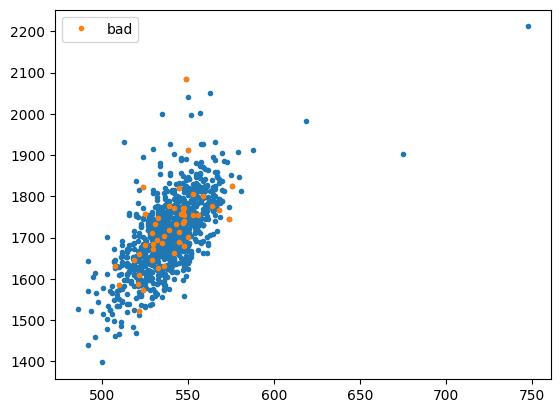

In [20]:
plt.plot(time_all,charge_all,'.')
plt.plot(time,charge,'.',label='bad')
plt.legend()

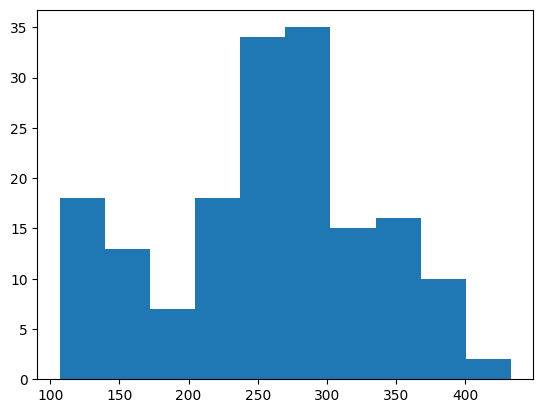

In [18]:
plt.hist(time);

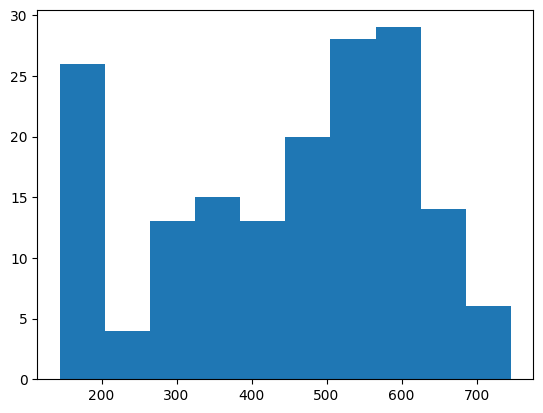

In [20]:
plt.hist(charge);

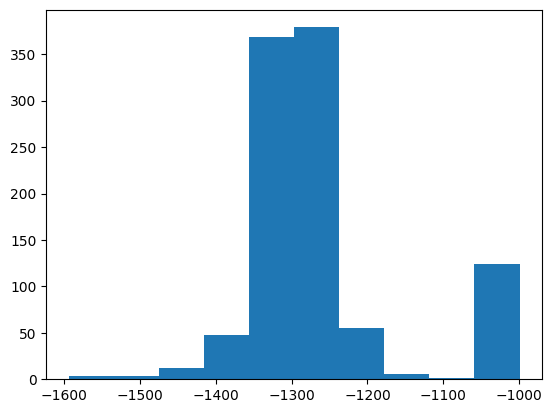

In [98]:
plt.hist(est['z']);

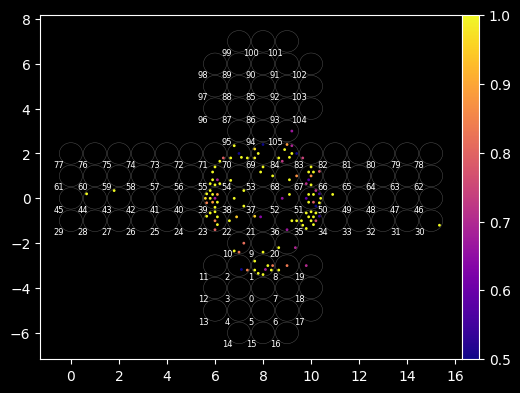

In [14]:
import sys
sys.path.insert(0, "../LicketFit/scripts")
sys.path.insert(0, "./scripts")
from plot_event import *
file = '/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/1kmu-_100MeV_x0y0zn1330_noE_noScat.npz'
plot_event(file,5,LF_data = False,vmin = 0.5,vmax=1)
file2 = '/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/mu-/1kmu-_500MeV_x0y0zn1330_noE_noScat.npz'
#plot_event(file2,1,LF_data = False)

In [6]:
sys.path.insert(0, "/eos/user/j/jrimmer/Geometry")
import os
from Geometry.Device import Device

hall = Device.open_file('/eos/user/j/jrimmer/Geometry/examples/wcte_bldg157.geo')
wcte = hall.wcds[0]


folder = '/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/work_dir/inverse_r_data/for_surface_fit/'
files = os.listdir(folder)
data = []
data_split = []
for file in files:
    if file[-4:] == 'dict':
        continue
    data.extend(np.load('./inverse_r_data/for_surface_fit/'+file))
    
    data_split.append(np.load('./inverse_r_data/for_surface_fit/'+file))
    

In [7]:
data_split[0][0]

array([3.70000000e+03, 8.26102815e-01, 7.53762857e+02, 1.81374995e+02,
       1.27574673e+02])

In [11]:
sys.path.insert(0, "../LicketyFit")
from model_muon_cherenkov_collapse import *
c_ang_vs_E = np.load('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/tables/mu_cAng_vs_E_n1344.npy')
c_ang = c_ang_vs_E[:,0]
energy_for_angle = c_ang_vs_E[:,1]


dEds = 0.2
# a = 0.3
# p = 7
a = 5.44
p = 0.74
def N(E,r):
    m = 105
    n = 1.344
    gamma = 1 + E/m
    beta = np.sqrt(1-(1/(gamma**2)))
    
    theta_c = theta_c_func(c_ang,energy_for_angle,E)
    
    first = rho/(r**2)
    
    second = dEds/(n*beta**3*gamma**3*np.sin(theta_c))
    
    
    
    return (1/r)*1/(1+a*second)**p

In [16]:
idx = 55

N_arr = []
for i in range(len(data_split[idx])):
    mpmt = int(data_split[idx][i][0]//100)
    
    pmt = int(data_split[idx][i][0]%100)
    pmt_loc = np.array(wcte.mpmts[mpmt].pmts[pmt].get_placement('design')['location'])
    rho = np.sqrt(pmt_loc[0]**2+pmt_loc[1]**2)
    
    cost = data_split[idx][i][1]
    
    r = data_split[idx][i][2]
    n = data_split[idx][i][3]
    E = data_split[idx][i][4]
    
    N_arr.append([E,r,N(E,r),n,cost])
    
    
N_arr = np.array(N_arr)

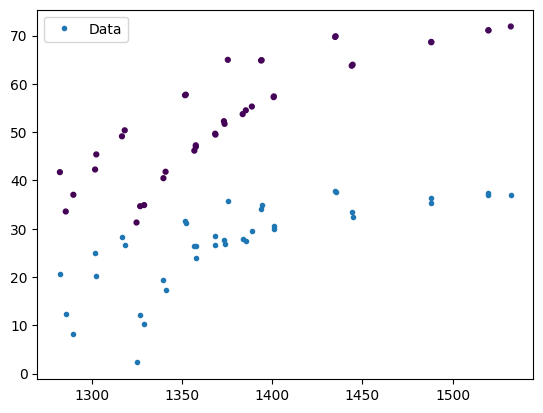

In [17]:
sc = plt.scatter(
    N_arr[:,1],
    N_arr[:,2]*1.7e5,
    c=N_arr[:,0],
    s=12,          # marker size
    cmap='viridis',vmin = 52,vmax =800 # change colormap if you want
)


plt.plot(N_arr[:,1],N_arr[:,3]/N_arr[:,4],'.',label='Data')

plt.legend()

In [229]:
idx = 75

pmts = data_split[idx][:,0]
cost = data_split[idx][:,1]
r = data_split[idx][:,2]

mask = r<400

In [230]:
pmts[mask]

array([3710., 5300., 5301., 5302., 5303., 5304., 5305., 5306., 5307.,
       5313., 5314., 5315., 5316., 5317., 5318.])